# Organizational Unit Types Analysis

Focused analysis of organizational unit types (Course Offerings, Sections, Groups) and activation status, based on the LMS `organizational_units` dataset.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

Dataset Paths:
  organizational_units      -> ../output/organizationalunits/organizationalunits/data

Loading datasets...

Loading organizational_units... ✓ (1,146,091 records, 14 columns)

Loaded 1 datasets successfully.

Removing outlier types that occur only once:
['Organization', '2025-09-02T07:00:00.000Z', '2024-09-03T07:00:00.000Z']

Organizational Units Dataset Overview (after removing singleton types)
Total Records: 1,146,088
Total Columns: 14

Columns: org_unit_id, organization, type, name, code, start_date, end_date, is_active, created_date, is_deleted, deleted_date, recycled_date, version, org_unit_type_id

First few records:
   org_unit_id                              organization     type  \
0    1003600.0  British Columbia Institute of Technology  Section   
1    1003602.0  British Columbia Institute of Technology  Section   
2    1003604.0  British Columbia Institute of Technology  Section   
3    1003606.0  British Columbia Institute of Technology  Section   
4    10036

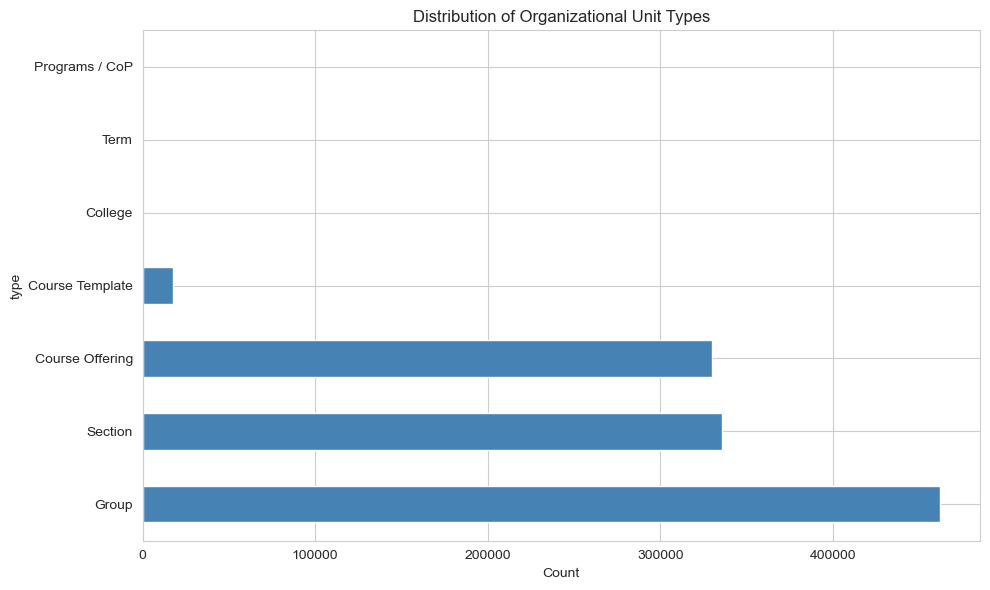


Key Organizational Unit Types (counts and simple ratios)
Course Offering :    330,041
Section         :    335,609
Group           :    462,269

Global ratios (approximate, using raw counts):
Sections per Course Offering (global): 1.02
Groups per Course Offering (global):   1.40
Groups per Section (global):           1.38


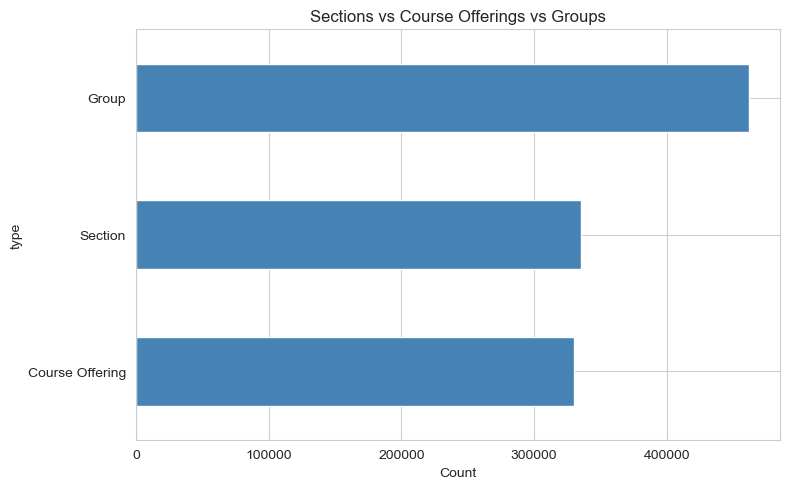


Total Course Offerings: 330,041

Heuristic x-list indicators (approximate):
Course offerings with code_token_count > 1: 16,429
Course offerings with 'x-list' in the name: 10,575

Total Sections:         335,609
Total Course Offerings: 330,041
Difference (Sections - Course Offerings): 5,568

Distribution of code_token_count (top 10):
code_token_count
1     313611
3       6925
5       2938
4       2792
6       1355
7       1259
2        693
8        318
9        117
10        29
Name: count, dtype: int64

Sample heuristic x-list course offerings:
                                                     name  \
357985                            HSIP – Student Workshop   
357986       Fostering Learning Online - May 2020 - Lynda   
357989                         Sandbox – Cameron Wyenberg   
357992                                   John Tan Sandbox   
357999                                     HMT Foundation   
358002                                 HMT Level 1 Online   
358003  Sandbox - Lev

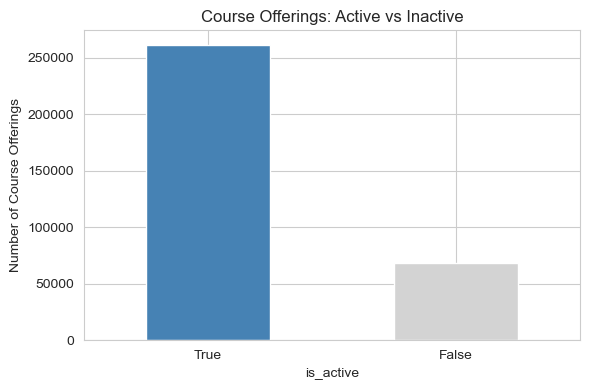


Course Offering activation by start_year (tail):
is_active   False   True  total  pct_active
start_year                                 
2012.0       6775  12925  19700   65.609137
2013.0      16075   3658  19733   18.537475
2014.0      16636   4304  20940   20.553964
2015.0      14482   5340  19822   26.939764
2016.0        997  21260  22257   95.520510
2017.0        779  21588  22367   96.517191
2018.0        788  21344  22132   96.439545
2019.0        790  23169  23959   96.702700
2020.0       1075  22973  24048   95.529774
2021.0        832  22705  23537   96.465140
2022.0        521  22853  23374   97.771028
2023.0        539  22868  23407   97.697270
2024.0       1237  21045  22282   94.448434
2025.0       2249  19660  21909   89.734812
2026.0       1328   4870   6198   78.573733

Total Group OUs: 462,269

Sample groups:
    org_unit_id           name                code is_active
12    1003572.0  NSPN-7735-CHL  Sec - 83292.202410      True
15    1003578.0  FNAM-3820-NET  Sec - 

In [4]:
from pathlib import Path

# Base directory where the ETL output CSVs live
base_path = Path('../output')

# We only need the organizational_units table for this analysis
# (other tables are joined in the main organizational_units_analysis notebook)
dataset_paths = {
    'organizational_units': base_path / 'organizationalunits/organizationalunits/data',
}

print("Dataset Paths:")
for name, path in dataset_paths.items():
    print(f"  {name:25s} -> {path}")


def load_dataset(path):
    """Load one or more CSV files from a directory.

    The organizational_units extract may be partitioned into multiple CSVs.
    This helper transparently concatenates them into a single DataFrame.
    """
    csv_files = list(path.glob('*.csv'))
    if not csv_files:
        print(f"Warning: No CSV files found in {path}")
        return None
    if len(csv_files) == 1:
        return pd.read_csv(csv_files[0])
    dfs = [pd.read_csv(f) for f in csv_files]
    return pd.concat(dfs, ignore_index=True)


print("\nLoading datasets...\n")
datasets = {}
for name, path in dataset_paths.items():
    print(f"Loading {name}...", end=" ")
    df = load_dataset(path)
    if df is not None:
        datasets[name] = df
        print(f"✓ ({len(df):,} records, {len(df.columns)} columns)")
    else:
        print("✗ (No data)")

print(f"\nLoaded {len(datasets)} datasets successfully.")

# ---------------------------------------------------------------------------
# 1. Prepare organizational_units and remove obvious type outliers
# ---------------------------------------------------------------------------

org_units = datasets['organizational_units']

# Some "type" values look like timestamps or one-off artifacts.
# We treat any type that occurs only once as an outlier and exclude it
# so that distributions and ratios focus on meaningful OU types.
raw_type_counts = org_units['type'].value_counts()
singleton_types = raw_type_counts[raw_type_counts == 1].index
if len(singleton_types) > 0:
    print("\nRemoving outlier types that occur only once:")
    print(list(singleton_types))
    org_units = org_units[~org_units['type'].isin(singleton_types)].copy()

print("\nOrganizational Units Dataset Overview (after removing singleton types)")
print("=" * 60)
print(f"Total Records: {len(org_units):,}")
print(f"Total Columns: {len(org_units.columns)}")
print(f"\nColumns: {', '.join(org_units.columns.tolist())}")

print("\nFirst few records:")
print(org_units.head())

# ---------------------------------------------------------------------------
# 2. High-level distribution of OU types
# ---------------------------------------------------------------------------

print("\nOrganizational Unit Type Distribution:")
print("=" * 60)
type_dist = org_units['type'].value_counts()
print(type_dist)

# Horizontal bar chart keeps the emphasis on relative volumes by type
plt.figure(figsize=(10, 6))
type_dist.plot(kind='barh', color='steelblue')
plt.xlabel('Count')
plt.title('Distribution of Organizational Unit Types')
plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------------
# 3. Focus on Course Offerings, Sections, and Groups
# ---------------------------------------------------------------------------

# These three OU types are central for the stakeholder questions:
# - Course Offering: the canonical course shell
# - Section: specific delivery instances of offerings
# - Group: intra-course structures used for cohorting / group work
key_types = ['Course Offering', 'Section', 'Group']

print("\nKey Organizational Unit Types (counts and simple ratios)")
print("=" * 60)
for t in key_types:
    count = type_dist.get(t, 0)
    print(f"{t:16s}: {count:10,d}")

course_offering_count = type_dist.get('Course Offering', 0)
section_count = type_dist.get('Section', 0)
group_count = type_dist.get('Group', 0)

# These global ratios are *not* precise per-course metrics, but they provide
# a quick sense of how far reality is from a naive "one-course, one-section"
# world and how pervasively groups are used.
if course_offering_count > 0:
    print("\nGlobal ratios (approximate, using raw counts):")
    print(f"Sections per Course Offering (global): {section_count / course_offering_count:.2f}")
    print(f"Groups per Course Offering (global):   {group_count / course_offering_count:.2f}")
if section_count > 0:
    print(f"Groups per Section (global):           {group_count / section_count:.2f}")

available_key_types = [t for t in key_types if t in type_dist.index]
if available_key_types:
    plt.figure(figsize=(8, 5))
    type_dist.loc[available_key_types].sort_values().plot(kind='barh', color='steelblue')
    plt.xlabel('Count')
    plt.title('Sections vs Course Offerings vs Groups')
    plt.tight_layout()
    plt.show()

# ---------------------------------------------------------------------------
# 4. Heuristic exploration of potential cross-listed course offerings ("x-lists")
# ---------------------------------------------------------------------------

course_offerings = org_units[org_units['type'] == 'Course Offering'].copy()
print(f"\nTotal Course Offerings: {len(course_offerings):,}")

# Normalise name/code to strings so we can apply simple text heuristics
course_offerings['code'] = course_offerings['code'].astype(str).fillna('')
course_offerings['name'] = course_offerings['name'].astype(str).fillna('')

# Many cross-listed offerings encode multiple CRNs / identifiers in the
# code field. As a simple proxy, we count space-separated tokens.
code_tokens = course_offerings['code'].str.strip().replace({'nan': ''}).str.split()
course_offerings['code_token_count'] = code_tokens.apply(len)

# Heuristic 1: multiple tokens in code may indicate multiple CRNs (x-list)
xlist_candidates = course_offerings[course_offerings['code_token_count'] > 1].copy()

# Heuristic 2: explicit "x-list" in the name
course_offerings['has_xlist_keyword'] = course_offerings['name'].str.contains('x-list', case=False, na=False)
keyword_xlists = course_offerings[course_offerings['has_xlist_keyword']].copy()

print("\nHeuristic x-list indicators (approximate):")
print("=" * 60)
print(f"Course offerings with code_token_count > 1: {len(xlist_candidates):,}")
print(f"Course offerings with 'x-list' in the name: {len(keyword_xlists):,}")

# Compare sections vs offerings to see how often there are multiple
# sections per offering overall.
sections_total = (org_units['type'] == 'Section').sum()
offerings_total = len(course_offerings)
print(f"\nTotal Sections:         {sections_total:,}")
print(f"Total Course Offerings: {offerings_total:,}")
print(f"Difference (Sections - Course Offerings): {sections_total - offerings_total:,}")

print("\nDistribution of code_token_count (top 10):")
print(course_offerings['code_token_count'].value_counts().head(10))

print("\nSample heuristic x-list course offerings:")
sample_cols = ['name', 'code', 'code_token_count']
print(xlist_candidates[sample_cols].head(10))

# ---------------------------------------------------------------------------
# 5. Activation status: evidence for "should not be active by default"
# ---------------------------------------------------------------------------

print("\nOverall Active vs Inactive across all org unit types:")
print("=" * 60)
print(org_units['is_active'].value_counts())

print("\nActive status by type:")
active_by_type = pd.crosstab(org_units['type'], org_units['is_active'])
active_by_type['total'] = active_by_type.sum(axis=1)

# Identify which column in the crosstab corresponds to the active state
true_col = None
for candidate in [True, 'True', 1, '1']:
    if candidate in active_by_type.columns:
        true_col = candidate
        break

if true_col is not None:
    active_by_type['pct_active'] = active_by_type[true_col] / active_by_type['total'] * 100
else:
    active_by_type['pct_active'] = np.nan

active_by_type = active_by_type.sort_values('total', ascending=False)
print(active_by_type.head(10))

# Focus specifically on Course Offerings, since "active course" is the
# key decision lever for reporting and operational processes.
co_active_counts = course_offerings['is_active'].value_counts()
print("\nCourse Offering Active Status (counts):")
print("=" * 60)
print(co_active_counts)

co_active_pct = co_active_counts / co_active_counts.sum() * 100
print("\nCourse Offering Active Status (%):")
print(co_active_pct.round(1))

plt.figure(figsize=(6, 4))
co_active_counts.plot(kind='bar', color=['steelblue', 'lightgray'])
plt.ylabel('Number of Course Offerings')
plt.title('Course Offerings: Active vs Inactive')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Look at activation by start year to see whether older offerings remain active.
course_offerings['start_date_parsed'] = pd.to_datetime(course_offerings['start_date'], errors='coerce')
course_offerings['start_year'] = course_offerings['start_date_parsed'].dt.year

co_year_active = course_offerings.groupby('start_year')['is_active'].value_counts().unstack(fill_value=0)
co_year_active['total'] = co_year_active.sum(axis=1)

true_col = None
for candidate in [True, 'True', 1, '1']:
    if candidate in co_year_active.columns:
        true_col = candidate
        break

if true_col is not None:
    co_year_active['pct_active'] = co_year_active[true_col] / co_year_active['total'] * 100

print("\nCourse Offering activation by start_year (tail):")
print(co_year_active.sort_index().tail(15))

# ---------------------------------------------------------------------------
# 6. High-level view of Group usage
# ---------------------------------------------------------------------------

# This is a global, not per-course, view of group creation. A richer
# analysis would join Group OUs back to their parent course shells.
groups = org_units[org_units['type'] == 'Group'].copy()
print(f"\nTotal Group OUs: {len(groups):,}")

print("\nSample groups:")
if not groups.empty:
    print(groups[['org_unit_id', 'name', 'code', 'is_active']].head(10))

if len(course_offerings) > 0:
    print(f"\nOverall Groups per Course Offering (global): {len(groups) / len(course_offerings):.2f}")

if section_count > 0:
    print(f"Overall Groups per Section (global):           {len(groups) / section_count:.2f}")